In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# MEMBACA GAMBAR DAN MENGUBAH KE GRAYSCALE

Langkah awal dilakukan proses pembacaan citra doomsday lalu mengubahnya ke dalam grayscale lalu ditampilkan.

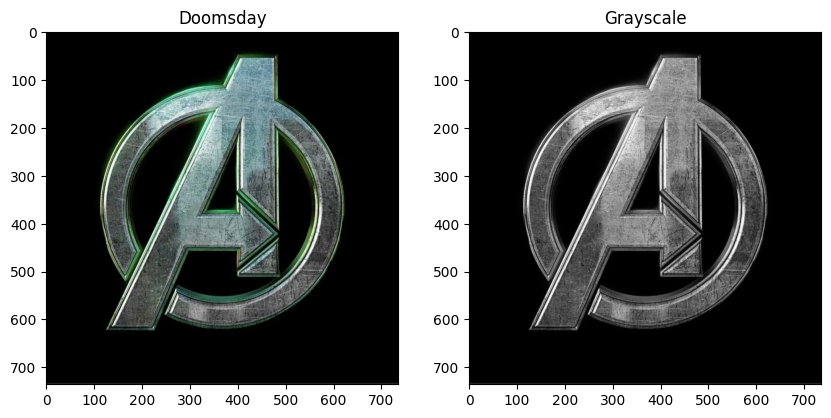

In [9]:
doomsday = plt.imread('doomsday.jpg')
doomsday_gray = cv.cvtColor(doomsday,cv.COLOR_RGB2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.title("Doomsday")
plt.imshow(doomsday)

plt.subplot(1, 2, 2)
plt.title("Grayscale")
plt.imshow(doomsday_gray, cmap='gray')

plt.show()

# DEKOMPOSISI WAVELET LEVEL 1
Langkah kedua melakukan dekomposisi wavelet level 1, dimana dengan menguraikan citra menjadi empat subband yang berbeda secara frekuensi dan juga arah, diamna subband LL akan berisi informasi citra asli, sementara LH, HL, dan HH menyimpan detail tepi pada frekuensi dan juga arah tertentu.

Proses dekomposisi menggunakan filter Haar yang digunakan untuk mengekstrak komponen frekuensi rendah dan tinggi berupa nilai rata-rata dan informasi tepi. Dimulai dengan melakukan konvolusi horizontal, downsampling kolom, kemudian konvolusi vertikal, dan diakhiri dengan downsampling baris. Dari hasil citra yang didapatkan, terlihat subband LL menghasilkan citra yang sangat mirip dengan citra asli. Sedangkan pada citra LH subband berupa citra berwarna abu-abu dengan kontur samar. Namun pada citra HL menghasilkan citra huruf A yang tampak lebih jelas dan halus dibanding subband LH namun tetap dengan dominasi warna abu-abu. Sedangkan citra HH yang dihasilkan mengambil perubahan intensitas diagonal citra yang menyebabkan subband HH tampak paling samar.

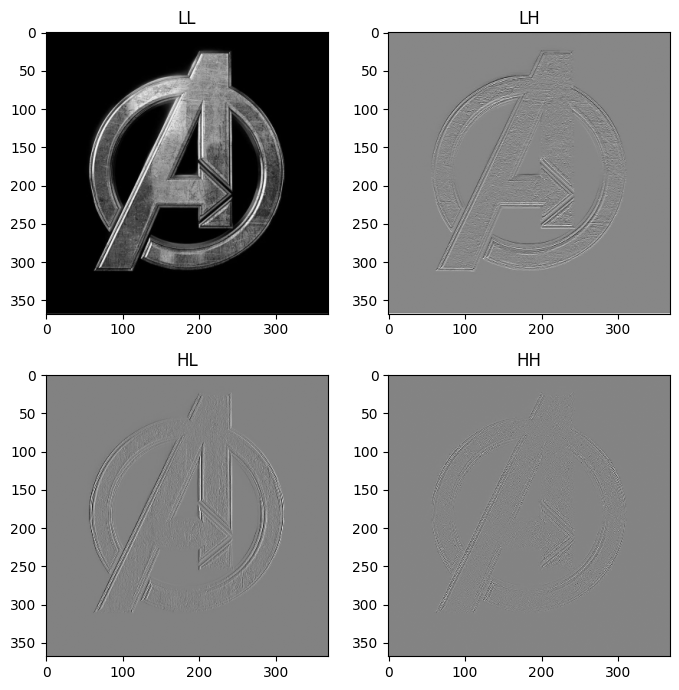

In [10]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HPF = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0,0),(0,ukuran_kernel-1)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            total = 0
            for x in range(len(kernel)):
                total += padd[i][j+x] * kernel[x]
            conv[i][j] = total

    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0,ukuran_kernel-1),(0,0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            total = 0
            for x in range(len(kernel)):
                total += padd[i+x][j] * kernel[x]
            conv[i][j] = total

    return conv

def downsampling_h(image):
    baris = image.shape[0]
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))

    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2

    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = image.shape[1]
    downsampled = np.zeros((baris, kolom))
    indeks = 0

    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2

    return downsampled

def normalisasi(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255

def wavelet(image):
    # LL
    konvolusil = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusil)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)

    # HL
    konvolusil = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusil)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)

    # LH
    konvolusil = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusil)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)

    # HH
    konvolusil = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusil)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)

    return (approximation, vertikal, horizontal, diagonal)

LL, HL, LH, HH = wavelet(doomsday_gray)

LL_norm = normalisasi((LL))
HL_norm = normalisasi((HL))
LH_norm = normalisasi((LH))
HH_norm = normalisasi((HH))

plt.figure(figsize=(7,7))

plt.subplot(2,2,1)
plt.imshow(LL_norm, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(LH_norm, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(HL_norm, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(HH_norm, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

# Thresholding Subband Selain LL Dengan Nilai Threshold = 150
Langkah ketiga pada soal diminta untuk melakukan thresholding dengan menggunakan subband LH, HL dan HH yang sudah di normalisasi, tujuan normalisasi agar rentang nilai intensitas antara 0–255. Selanjutnya thresholding diterapkan dengan menggunakan nilai batas = 150, di mana setiap piksel bernilai lebih dari 150 akan diubah menjadi warna putih (255) dan intensitas yang berada di bawah batas ambang akan berubah menjadi hitam (0), sehingga akan menghasilkan citra dalam format biner.

Pada subband HL piksel-piksel putih yang tersisa setelah thresholding menandai titik lokasi dengan perubahan intensitas horizontal yang cukup besar. Struktur huruf A dan tepi lingkaran masih dapat dikenali walaupun beberapa noise menghilang. Sedangkan subband LH mendeteksi tepi horizontal, sehingga piksel putih yang muncul pada terpi atau bagian vertikal menampilkan kontur yang kuat. Jika dibandingkan dengan subband HL dan HH, hasil thresholding LH menghasilkan kontur paling lengkap dengan lingkaran dan logo tampak lebih tebal. Sedangkan subband HH menampilkan piksel putih paling sedikit dan tidak merata.

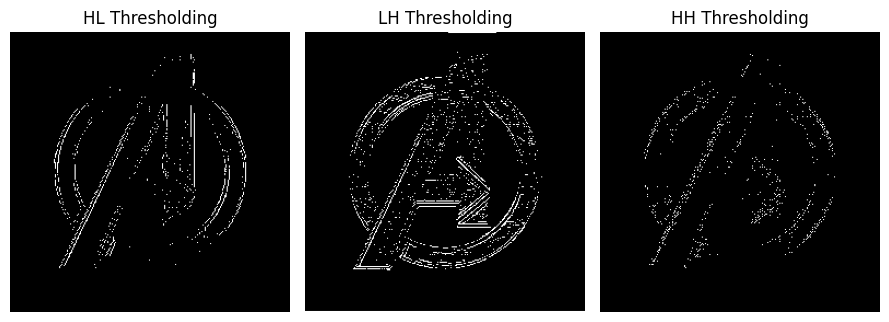

In [11]:
LL_norm = cv.resize(LL_norm, (256, 256))
HL_norm = cv.resize(HL_norm, (256, 256))
LH_norm = cv.resize(LH_norm, (256, 256))
HH_norm = cv.resize(HH_norm, (256, 256))

def fungsi_threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            canvas[i,j] = 255 if img[i,j] > batas else 0
    return canvas

thres_HL = fungsi_threshold(HL_norm, 150)
thres_LH = fungsi_threshold(LH_norm, 150)
thres_HH = fungsi_threshold(HH_norm, 150)

plt.figure(figsize=(9, 9))
plt.subplot(1,3,1)
plt.imshow(thres_HL, cmap='gray')
plt.title('HL Thresholding')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thres_LH, cmap='gray')
plt.title('LH Thresholding')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(thres_HH, cmap='gray')
plt.title('HH Thresholding')
plt.axis('off')

plt.tight_layout()
plt.show()

# HASIL MORFOLOGI CITRA (CLOSING) PADA HASIL THRESHOLD
Langkah ke empat melakukan operasi closing, operasi closing merupakan kombinasi dari operasi dilasi dan erosi sehingga dapat digunakan untuk menutup celah-celah kecil antara piksel-piksel putih pada subband-subband, sehingga kontur logo menjadi lebih rapat dan dapat terhubung. Pada subband HL menghasilkan kontur yang lebih jelas pada huruf A citra dan tepi lingkaran dibandingkan sebelumnya. Dimaan piksel sebelumnya terdapat noise yang terputus-putus namun setelah dilakukan proses closing, noise menjadi terhubung dan membentuk tepi yang lebih padat, sedangkan subband LH menampilkan hasil yang lebih jelas dan saling terhubung satu sama lain sehingga membentuk kontur garis tepi yang mirip dengan citra asli, baik huruf A maupun lingkaran tampak jelas terlihat. Sedangkan pada subband diagonal atau HH menghasilkan garis-garis diagonal logo seperti kemiringan huruf A tampak lebih jelas setelah dilakukan proses closing, meskipun hasil keseluruhannya masih tampak lebih menyebar dibanding HL maupun LH.

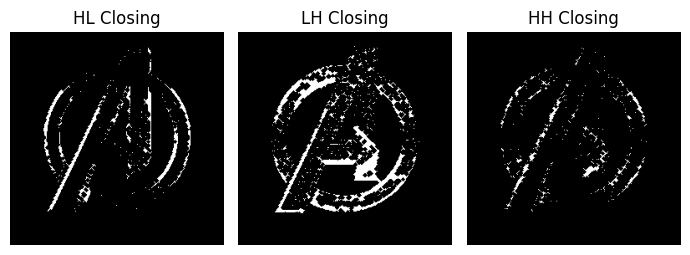

In [ ]:
# DILASI
def fungsi_dilasi(image,kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height//2
    hasil = np.zeros((height, width))
    for i in range(center, height-center):
        for j in range(center, width-center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            hasil[i+k-center,j+l-center] =255
            else:
                if hasil[i,j] !=255:
                    hasil[i,j] = 0
    return hasil

# EROSI
def fungsi_erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros_like(image)

    for i in range(center, height-center):
        for j in range(center, width-center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

# Closing
def fungsi_closing(img, kernel):
    return fungsi_erosi(fungsi_dilasi(img, kernel), kernel)

kernel15 = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
])

hasil_closing_HL = fungsi_closing(thres_HL, kernel15)
hasil_closing_LH = fungsi_closing(thres_LH, kernel15)
hasil_closing_HH = fungsi_closing(thres_HH, kernel15)

plt.figure(figsize=(7,7))

plt.subplot(1,3,1)
plt.imshow(hasil_closing_HL, cmap='gray')
plt.title('HL Closing')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_closing_LH, cmap='gray')
plt.title('LH Closing')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_closing_HH, cmap='gray')
plt.title('HH Closing')
plt.axis('off')

plt.tight_layout()
plt.show()

# Rekonstruksi LL, HL, LH, HH
Langkah kelima dilakukan proses rekonstruksi pada subband-subband yang telah di dapat kan sebelumnya, dimana rekonstruksi menyatukan kembali subband-subband hasil dekomposisi wavelet. Tiap subband diproses dengan melalui upsampling terlebih dahulu yang digunakan untuk mengembalikan ukuran ke resolusi asli, kemudian melakukan konvolusi pada hasil upsampling dengan filter yang sesuai. Pada subband LL dan LH di lakukan upsampling vertikal lalu dilakukan konvolusi dengan LPF dan HPF arah vertikal, setelah itu dijumlahkan pada tiap hasil konvolusi dari LL dan LH, setelah itu dilakukan hal yang sama subband HL dan HH yang nantinya tiap hasil akan dilakukan penjumlahan kembali untuk menghasilkan citra rekonstruksi. Citra hasil rekonstruksi menampilkan logo Avengers dengan kualitas yang sangat mirip dengan citra asli, terlihat gradasi dan kontras yang tetap terjag, yang menandakan bahwa proses rekonstruksi dapat mengembalikan citra ke kondisi yang mirip dengan informasi aslinya.

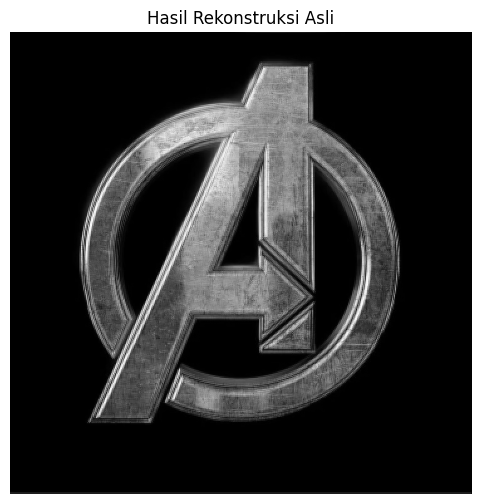

In [15]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            upsampled[i*2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            upsampled[i][j*2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)
    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)
    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)
    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)
    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)
    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)
    hasil = konvolusiL2 + konvolusiH2
    return hasil

hasil_rekonstruksi = rekonstruksi(LL, LH, HL, HH)

plt.figure(figsize=(6,6))
plt.imshow(hasil_rekonstruksi, cmap='gray')
plt.title('Hasil Rekonstruksi Asli')
plt.axis('off')
plt.show()

# REKONSTRUKSI LL = 0 DAN LH, HL, HH LEVEL 1
Langkah ke enam dilakukan proses rekonstruksi dengan mengganti nilai subband LL = 0, subband LL diganti dengan menggunakan matriks berisi nol semua menggunakan "np.zeros_like(LL)". Dengan begitu seluruh frekuensi rendah terhapus, sehingga proses rekonstruksi sepenuhnya pada subband LH, HL, dan HH saja. Pada citra hasil rekonstruksi LL = 0 terlihat hampir seluruh citra berwarna abu-abu namun logo Avengers masi terlihat walaupun minim dan tipis. Dengan LL yang bernilai 0 menyebabkan hilangnya informasi asli, sehingga kontras yang dihasilkan jauh lebih lemah dibanding hasil rekonstruksi sebelumnya. Dengan begitu dapat disimpulkan bahwa subband detail LH, HL, dan HH level 1 hanya dapat memberikan informasi tepi tanpa ada informasi kontras yang dapat mengubah tampilan citra menjadi mendekati citra aslinya.

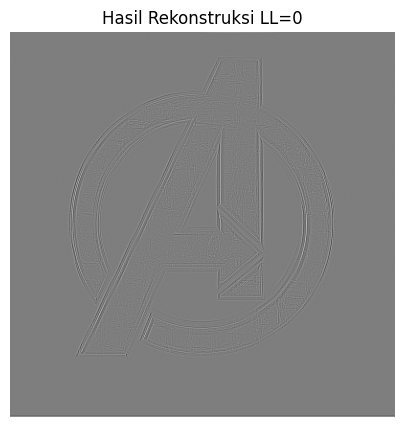

In [17]:
LL_nol = np.zeros_like(LL)

rekonstruksi0 = rekonstruksi(LL_nol, LH, HL, HH)
rekonstruksi0 = normalisasi(rekonstruksi0)

plt.figure(figsize=(5,5))
plt.imshow(rekonstruksi0, cmap='gray')
plt.title('Hasil Rekonstruksi LL=0')
plt.axis('off')

plt.show()

# REKONSTRUKSI LL = 0, DENGAN LH, HL, HH YANG TELAH DI PROSES SEBELUMNYA (CLOSING)
Langkah ke tujuh melakukan rekonstruksi dengan mengganti semua nilai LL dengan 0 kemudian menggunakan "hasil_closing_LH", "hasil_closing_HL", dan "hasil_closing_HH" yang merupakan hasil dari proses thresholding dan morfologi closing. Ketiga subband menghasilkan kontur logo yang terlihat lebih jelas dan tebal yang dihasilkan karena adanya operasi closing yang sebelumnya menutup celah-celah kecil. Pada citra hasil rekonstruksi LL = 0 dan LH, HL, dan HH hasil closing menampilkan citra yang cenderung kasar dengan latar belakang abu-abu yang tetap mendominasi karena subband LL yang bernilai nol. Dengan begitu dapat disimpulkan bahwa subband hasil closing dalam rekonstruksi dapat menghasilkan kontur yang lebih kasar namun lebih terlihat jelas dibanding dengan subband tanpa proses closing.

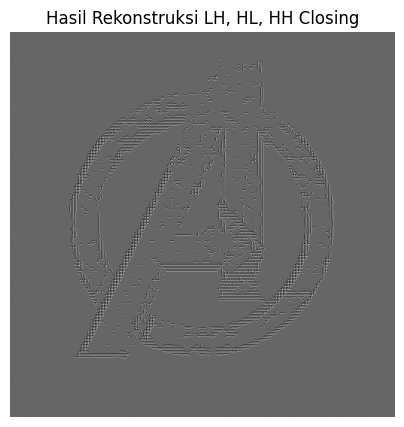

In [19]:
LL_nol = np.zeros_like(LL)
LL_nol = cv.resize(LL_nol, (256, 256))

rekonstruksi_closing = rekonstruksi(
    LL_nol,
    hasil_closing_LH,
    hasil_closing_HL,
    hasil_closing_HH
)

rekonstruksi_closing = normalisasi(rekonstruksi_closing)

plt.figure(figsize=(5,5))
plt.imshow(rekonstruksi_closing, cmap='gray')
plt.title('Hasil Rekonstruksi LH, HL, HH Closing')
plt.axis('off')

plt.show()

# MENAMPILKAN HASIL CITRA SOAL NOMOR 5
Langkah terakhir yaitu menampilkan seluruh hasil rekonstruksi untuk dapat dilakukan perbandingan, dimana pada citra 1 atau ctra hasil rekonstruksi asli menggunakan subband LL, LH, HL, dan HH asli sehingga menghasilkan citra yang sangat mirip dengan gambar aslinya, sedangkan pada citra rekonstruksi LL=0 dengan LL bernilai nol menghasilkan citra berwarna abu-abu, dengan logo yang terlihat tipis dan halus. Berbeda dengan citra hasil rekonstruksi LH, HL, HH closing yang garis-garis kontur logo tampak lebih tebal dan kasar dikarenakan proses closing yang dilakukan. Pada citra ke empat yaitu citra asli Doomsday yang ditampilkan sebagai acuan untuk membandingkan seluruh hasil rekonstruksi, dimana dari hasil perbandingan terlihat bahwa citra hasil rekonstruksi asli berhasil mendekati kondisi asli citra, sedangkan citra hasil rekonstruksi pada subplot 2 dan 3 hanya mampu menangkap sebagian kecil dari keseluruhan informasi karena tidak ada nya nilai LL yang disebabkan karena penggantian seluruh nilai LL menjadi 0.

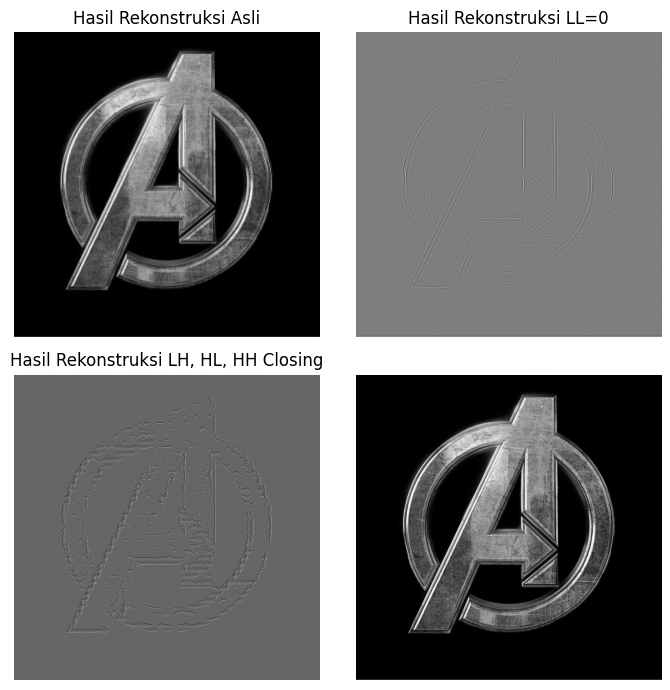

In [20]:
plt.figure(figsize=(7,7))

plt.subplot(2,2,1)
plt.imshow(hasil_rekonstruksi, cmap = 'gray')
plt.title('Hasil Rekonstruksi Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(rekonstruksi0, cmap = 'gray')
plt.title('Hasil Rekonstruksi LL=0')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(rekonstruksi_closing, cmap = 'gray')
plt.title('Hasil Rekonstruksi LH, HL, HH Closing')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(doomsday_gray, cmap = 'gray')
plt.axis('off')

plt.tight_layout()
plt.show()